In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [14]:
df = pd.read_csv("data/processed/airbnb_feature_engineered.csv")

y = df['price_per_night']

In [15]:
#Dataset for ML
X_ml = df[['listing','nights','month','monthly_demand','weekday','is_weekend','stay_category','booking_window','season']]

X_encoded = pd.get_dummies(
    X_ml,
    columns=['listing','weekday','stay_category','booking_window','season'],
    drop_first=True
)

KeyError: "['monthly_demand'] not in index"

In [ ]:
#Train Test Split
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

Model 1 — Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_ml, y_train_ml)

pred_lr = lr.predict(X_test_ml)

mae_lr = mean_absolute_error(y_test_ml, pred_lr)
r2_lr = r2_score(y_test_ml, pred_lr)

Model 2 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)

rf.fit(X_train_ml, y_train_ml)

pred_rf = rf.predict(X_test_ml)

mae_rf = mean_absolute_error(y_test_ml, pred_rf)
r2_rf = r2_score(y_test_ml, pred_rf)

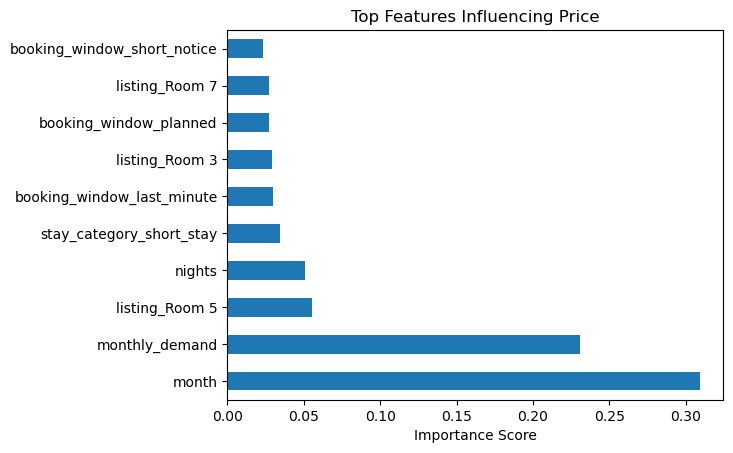

In [ ]:
#Feature Importance using random forest


feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train_ml.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='barh')

plt.title("Top Features Influencing Price")
plt.xlabel("Importance Score")
plt.show()

Model 3 — CatBoost

In [ ]:
from catboost import CatBoostRegressor

cat_features = ['listing','weekday','stay_category','booking_window','season']

X_cb = df[['listing','nights','month','monthly_demand','weekday','is_weekend','stay_category','booking_window','season']]

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_cb, y, test_size=0.2, random_state=42
)

cat_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=0
)

cat_model.fit(X_train_cb, y_train_cb, cat_features=cat_features)

pred_cat = cat_model.predict(X_test_cb)

mae_cat = mean_absolute_error(y_test_cb, pred_cat)
r2_cat = r2_score(y_test_cb, pred_cat)

Model 4 — XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train_ml, y_train_ml)

pred_xgb = xgb.predict(X_test_ml)

mae_xgb = mean_absolute_error(y_test_ml, pred_xgb)
r2_xgb = r2_score(y_test_ml, pred_xgb)

Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "CatBoost", "XGBoost"],
    "MAE": [mae_lr, mae_rf, mae_cat, mae_xgb],
    "R2 Score": [r2_lr, r2_rf, r2_cat, r2_xgb]
})

print(comparison)

               Model         MAE  R2 Score
0  Linear Regression  289.725797  0.320056
1      Random Forest  238.532947  0.509940
2           CatBoost  237.763985  0.503020
3            XGBoost  256.738163  0.460636


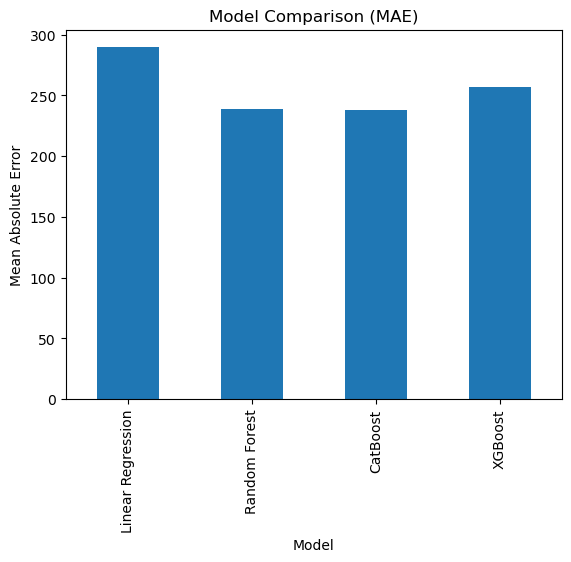

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Model")["MAE"].plot(kind="bar")

plt.title("Model Comparison (MAE)")
plt.ylabel("Mean Absolute Error")
plt.show()

In [ ]:
import joblib

joblib.dump(cat_model, "src/pricing_model.pkl")

['src/pricing_model.pkl']